EBM 모델 학습 중...
학습 완료!


/tmp/ipykernel_299/4216160650.py:131: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_299/4216160650.py:131: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_299/4216160650.py:131: UserWarning: Glyph 53748 (\N{HANGUL SYLLABLE TOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_299/4216160650.py:131: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_299/4216160650.py:131: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_299/4216160650.py:131: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_299/4216160650.py:131: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_l

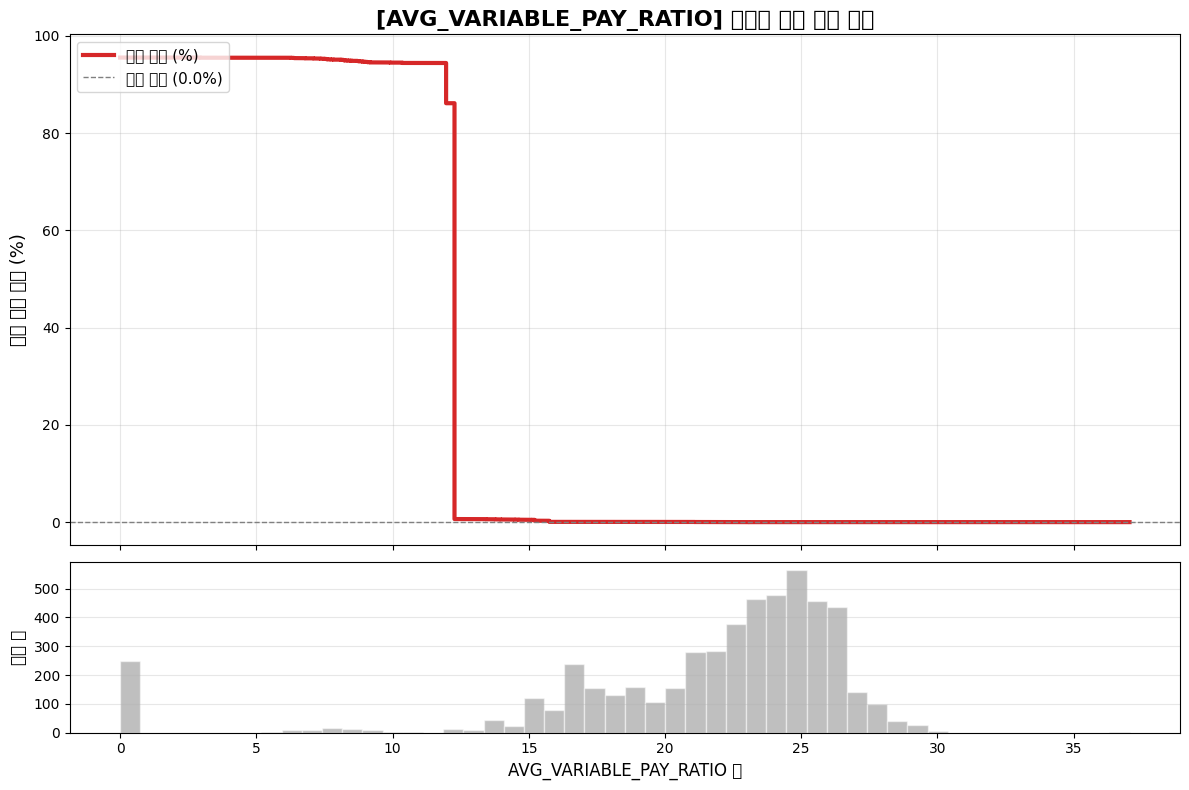

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec  # 그래프 레이아웃용
from interpret.glassbox import ExplainableBoostingClassifier

# --- 1. 한글 폰트 설정 ---
def set_korean_font():
    font_names = [f.name for f in fm.fontManager.ttflist]
    if 'NanumGothic' in font_names:
        plt.rcParams['font.family'] = 'NanumGothic'
    elif 'Malgun Gothic' in font_names:
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif 'AppleGothic' in font_names:
        plt.rcParams['font.family'] = 'AppleGothic'
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'

set_korean_font()
plt.rcParams['axes.unicode_minus'] = False

# --- 2. 데이터 준비 & 전처리 ---
master_df_encoded = pd.read_csv('ml_master_table.csv')

# 데이터 타입 정리
for col in master_df_encoded.columns:
    if master_df_encoded[col].dtype == 'object' and col not in ['EMP_ID', 'CURRENT_EMP_YN', 'IS_LEAVER']:
        master_df_encoded[col] = pd.to_numeric(master_df_encoded[col], errors='coerce')
master_df_encoded.fillna(master_df_encoded.median(numeric_only=True), inplace=True)

# --- 3. 데이터 비율 9:1 조정 ---
df_leavers = master_df_encoded[master_df_encoded['IS_LEAVER'] == 1]
df_active = master_df_encoded[master_df_encoded['IS_LEAVER'] == 0]

n_leavers = len(df_leavers)
n_required_active = n_leavers * 9 

# 재직자 뻥튀기 (Oversampling)
df_active_oversampled = df_active.sample(n=n_required_active, replace=True, random_state=42)
balanced_df = pd.concat([df_leavers, df_active_oversampled], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

drop_cols = ['EMP_ID', 'CURRENT_EMP_YN', 'IS_LEAVER']
feature_cols = [col for col in balanced_df.columns if col not in drop_cols]

X_train = balanced_df[feature_cols].astype(float)
y_train = balanced_df['IS_LEAVER'].astype(float)

# -----------------------------------------------------------------------------
# 4. EBM 모델 학습 (수정됨)
# -----------------------------------------------------------------------------

# [핵심 수정] feature_names 파라미터에 컬럼명 리스트를 명시적으로 전달합니다.
ebm = ExplainableBoostingClassifier(
    feature_names=feature_cols,  # <--- 이렇게 직접 넣어주면 절대 None이 되지 않습니다.
    random_state=42,
    n_jobs=-1,
    interactions=0
)

print("EBM 모델 학습 중...")
ebm.fit(X_train, y_train)
print("학습 완료!")


# =============================================================================
# 🎨 Matplotlib을 활용한 Global Explanation 시각화 (동일)
# =============================================================================

# 1. 시그모이드 함수 정의 (Log Odds -> Probability 변환기)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 2. 가장 중요한 변수(Top 1) 선택
ebm_global = ebm.explain_global()
importances = pd.Series(ebm.term_importances(), index=ebm.feature_names)
top_feature_name = importances.sort_values().index[-1] # 가장 중요한 변수
feature_idx = ebm.feature_names.index(top_feature_name)

# 3. 데이터 추출
data = ebm_global.data(feature_idx)
x_vals = np.array(data['names'])
y_scores = np.array(data['scores'])

# -----------------------------------------------------------------------------
# [핵심 로직] 점수(Score)를 확률(Probability %)로 변환
# -----------------------------------------------------------------------------
# EBM의 예측값 = (개별 변수의 점수) + (모델의 절편, Intercept)
# 이 값을 시그모이드 함수에 넣으면 0~1 사이의 확률이 됩니다.
intercept = ebm.intercept_[0] if hasattr(ebm.intercept_, '__iter__') else ebm.intercept_
y_probs = sigmoid(y_scores + intercept) * 100  # % 단위 변환

# 기준선(Base Rate): 아무 변수의 영향도 받지 않았을 때의 기본 확률
base_prob = sigmoid(intercept) * 100
# -----------------------------------------------------------------------------

# 4. 그래프 그리기 데이터 준비 (Step Plot 길이 맞추기)
x_plot = x_vals
y_plot = list(y_probs) + [y_probs[-1]]

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1]) 

# (A) 확률 영향도 그래프 (Line Plot)
ax0 = plt.subplot(gs[0])

# 빨간색 굵은 실선으로 확률 변화 표시
ax0.step(x_plot, y_plot, where='post', color='#d62728', linewidth=3, label='퇴사 확률 (%)')

# 기준선 (Base Rate) 표시
ax0.axhline(base_prob, color='gray', linestyle='--', linewidth=1, label=f'기본 확률 ({base_prob:.1f}%)')

ax0.set_title(f"[{top_feature_name}] 구간별 예상 퇴사 확률", fontsize=16, fontweight='bold')
ax0.set_ylabel("예상 퇴사 확률 (%)", fontsize=13)
ax0.grid(True, alpha=0.3)
ax0.legend(loc='upper left', fontsize=11)
ax0.set_xticklabels([]) # X축 공유를 위해 숨김

# Y축 범위 설정 (0~100%로 고정하면 더 직관적일 수 있음, 필요시 주석 해제)
# ax0.set_ylim(0, 105) 

# (B) 데이터 분포 (Histogram)
ax1 = plt.subplot(gs[1])
feature_data = X_train[top_feature_name]

ax1.hist(feature_data, bins=50, color='gray', alpha=0.5, edgecolor='white')
ax1.set_xlabel(f"{top_feature_name} 값", fontsize=12)
ax1.set_ylabel("인원 수", fontsize=12)
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05) 
plt.show()